# Delay Discount

## Imports

In [123]:
import numpy as np
import pandas as pd
import seaborn as sns
import uuid
import matplotlib.pyplot as plt

## Experimental Design

### Independent variables

- The amount range of the offer 
- Order of the offers

### Dependent Variables

- Response time
- Participant's Choice

### Trials

There are 3 sets of trials. First one has 10 low amount offers, second one has 10 high amount offers and the last one has low amount of offers as well. The offers in the first and the last sets are the same but given in a random order to each participant and set.


## Data Loading

In [124]:
from pathlib import Path

data_dir = Path("data")

file_list = []
for f in data_dir.glob("*.csv"):
	file_list.append(f)

Number of participants:

In [125]:
n_participants = len(file_list)
n_participants

13

A data frame for a single participant

In [126]:
df = pd.read_csv("data/133489_delay_discount_2026-05-11_13h49.12.465.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   instructions.started     1 non-null      float64
 1   instructions.stopped     1 non-null      float64
 2   key_resp_start.keys      1 non-null      str    
 3   key_resp_start.rt        1 non-null      float64
 4   key_resp_start.duration  0 non-null      float64
 5   participant              32 non-null     int64  
 6   session                  32 non-null     int64  
 7   date                     32 non-null     str    
 8   expName                  32 non-null     str    
 9   psychopyVersion          32 non-null     str    
 10  OS                       32 non-null     str    
 11  frameRate                32 non-null     float64
 12  trial.started            30 non-null     float64
 13  trial.stopped            30 non-null     float64
 14  key_resp.keys            30 non-null   

## Data Tidying

My main goal is to compare the participant behavior in between sets. There should be 4 columns named: set(low1, high, low2), trial(1-10), response_time, now_or_delay

The number of rows is the number of participants multiplied by the number of trials, which is 14x30=420. 

Lets check the beginning and the end of our data:

In [127]:
df.head(3)

,instructions.started,instructions.stopped,key_resp_start.keys,key_resp_start.rt,key_resp_start.duration,participant,session,date,expName,psychopyVersion,...,trials_2.thisN,trials_2.thisIndex,trials_2.ran,trials_3.thisRepN,trials_3.thisTrialN,trials_3.thisN,trials_3.thisIndex,trials_3.ran,bye.started,bye.stopped
0,0.0003,13.0597,space,13.0425,NaN,133489,1,2026-05-11_13h49.12.465,delay_discount,2026.1.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,133489,1,2026-05-11_13h49.12.465,delay_discount,2026.1.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,133489,1,2026-05-11_13h49.12.465,delay_discount,2026.1.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [128]:
df.tail(3).iloc[:,-4:]

,trials_3.thisIndex,trials_3.ran,bye.started,bye.stopped
29,6.0,1.0,NaN,NaN
30,4.0,1.0,NaN,NaN
31,NaN,NaN,135.356,138.3557


The first row is the instruction part whereas the last row is the finish screen. So let's crop them.

In [129]:
df = df.iloc[1:-1].reset_index(drop=True)

Now we need to filter the values we want to have in our dataset. I wrote a simple function to deduct the answer of the participant.

In [130]:
set_values = np.concat([np.repeat("low1", 10), np.repeat("high", 10), np.repeat("low2", 10)]).tolist()
trial_values = np.tile(np.arange(1, 11), 3).tolist()
response_time_values = df["key_resp.rt"].values.tolist()

def is_delay(key, amount1):
    if key == "left":
        return 0 if "now" in amount1 else 1
    
    elif key == "right":
        return 1 if "now" in amount1 else 0

is_delay_values = [is_delay(k, a) for k, a in zip(df["key_resp.keys"], df["amount1"])]

Let's create distinct uid's with the uuid package.

In [131]:
short_id = str(uuid.uuid4())[:8]
short_id = np.repeat(short_id, 120)

The code below, does these calculations for each participant and puts it into tidy_df.

In [132]:
set_values = np.concat([np.repeat("low1", 10), np.repeat("high", 10), np.repeat("low2", 10)]).tolist()
trial_values = np.tile(np.arange(1, 11), 3).tolist()
clean_df_list = []
for f in file_list:
    # read df
    df = pd.read_csv(f)
    # drop last and first rows
    df = df.iloc[1:-1].reset_index(drop=True)
    # get variables
    response_time_values = df["key_resp.rt"].values.tolist()
    is_delay_values = [is_delay(k, a) for k, a in zip(df["key_resp.keys"], df["amount1"])]
    
    # generate an id
    short_id = np.repeat(str(uuid.uuid4())[:8], 30)
    # create tidy df
    df_clean = pd.DataFrame({
        "participant_id": short_id,
        "set": set_values,
        "trial": trial_values,
        "response_time": response_time_values,
        "is_delay": is_delay_values,
    })
    clean_df_list.append(df_clean)

tidy_df = pd.concat(clean_df_list, ignore_index=True)
tidy_df

,participant_id,set,trial,response_time,is_delay
0,6f2bd4b7,low1,1,3.657500,1
1,6f2bd4b7,low1,2,4.251600,0
2,6f2bd4b7,low1,3,4.609000,1
3,6f2bd4b7,low1,4,3.615900,0
4,6f2bd4b7,low1,5,6.625600,1
...,...,...,...,...,...
385,b5013564,low2,6,1.848542,1
386,b5013564,low2,7,1.408796,0
387,b5013564,low2,8,1.187769,1
388,b5013564,low2,9,2.685312,0


Let's write this to a csv file.

In [133]:
tidy_df.to_csv("tidy_df.csv")

## Plotting

### Response Time

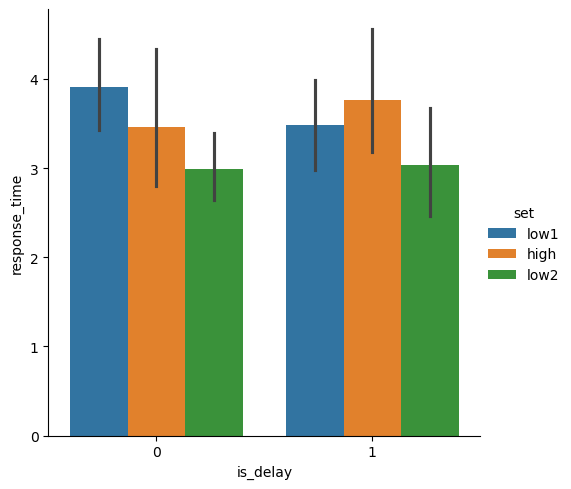

In [134]:
sns.catplot(data=tidy_df, x="is_delay", y="response_time", hue="set", kind="bar", errorbar="ci");

### Participant's Choice

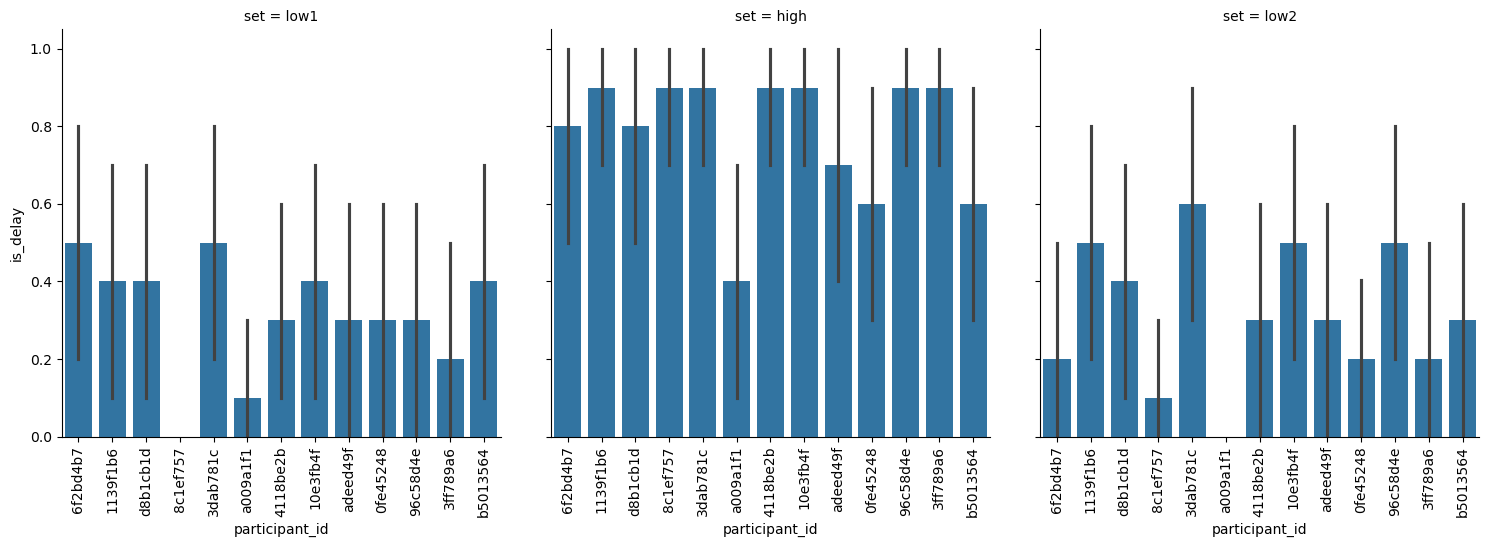

In [135]:
g = sns.catplot(data=tidy_df, x="participant_id", y="is_delay", col="set", kind="bar", errorbar="ci")
g.set_xticklabels(rotation=90)

## Hypothesis Test

My hypothesis was there is a significant difference in the participant behavior in between first and last low values. To test my hypothesis, I can run a paired t-test. 

If I define the participant behavior by the delay count, I'd run this:

In [136]:
from scipy import stats

delay_only = tidy_df[tidy_df['is_delay'] == 1]

counts = delay_only.groupby(['participant_id', 'set']).size().unstack(fill_value=0)

t_stat, p_value = stats.ttest_rel(counts['low1'], counts['low2'])

print(f"t-statistics: {t_stat}")
print(f"p-value: {p_value}")


t-statistics: 0.0
p-value: 1.0


p>0.05, so we can say that there is no significant difference in participant's choices depending on the order of the low values.

If I define the participant behavior by the response time, I'd run this:

In [137]:
rt_df = tidy_df.groupby(['participant_id', 'set'])['response_time'].mean().reset_index()
wide_rt_df = rt_df.pivot(index='participant_id', columns='set', values='response_time').reset_index()

wide_rt_df = wide_rt_df[['participant_id', 'low1', 'high', 'low2']]

t_stat, p_value = stats.ttest_rel(wide_rt_df['low1'],wide_rt_df['low2'])

print(f"t-statistics: {t_stat}")
print(f"p-value: {p_value}")

t-statistics: 3.4528635215529975
p-value: 0.004779663728581746


p<0.05, there is a significant difference in response time depending on the order of the low values.